In [1]:
SQLITE_2_PATH = './data/db2copia.sqlite3'
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def execute_query(db, query):
    conn = sqlite3.connect(db)
    cur = conn.cursor()
    cur.execute(query)
    rows = cur.fetchall()
    conn.commit()
    conn.close()
    return rows

In [3]:
execute_query(SQLITE_2_PATH, "SELECT DISTINCT type FROM moves")

[('Blitz',),
 ('Rapid',),
 ('Bullet',),
 ('Classical',),
 ('UltraBullet',),
 ('Correspondence',)]

In [4]:
white_elo = execute_query(SQLITE_2_PATH, "SELECT white_elo FROM moves")

In [5]:
np_white_elo = np.array(white_elo)

In [6]:
unique, counts = np.unique(white_elo, return_counts=True)
print(unique)
print(counts)

[ 800  803  804 ... 2799 2809 2819]
[2191   27   66 ...   47   39   55]


In [7]:
interval_size = 100
min_value = unique.min()
max_value = unique.max()
bins = np.arange(min_value, max_value + interval_size, interval_size)

digitized = np.digitize(unique, bins)

In [8]:
binned_counts = np.zeros(len(bins) - 1)
for i in range(len(bins) - 1):
    binned_counts[i] = counts[digitized == i + 1].sum()
binned_counts

array([1.60000e+04, 3.52040e+04, 5.57840e+04, 7.26430e+04, 9.15480e+04,
       1.05922e+05, 1.04765e+05, 1.24459e+05, 1.01732e+05, 8.48320e+04,
       6.87250e+04, 5.22790e+04, 3.72440e+04, 2.04470e+04, 1.17650e+04,
       6.51600e+03, 3.88400e+03, 4.98200e+03, 4.85000e+02, 6.90000e+02,
       9.40000e+01])

In [9]:
elo_groups = np.arange(start=800, stop=2900, step=100)

In [10]:
def bar_plot(x, y):
    plt.figure(figsize=(10, 6))
    plt.bar(x, y, width=50)
    plt.title('Number of moves by elo group')
    plt.xlabel('Elo')
    plt.ylabel('Count')
    plt.xticks(x, [f'{i}' for i in x])
    plt.tight_layout()
    plt.show()

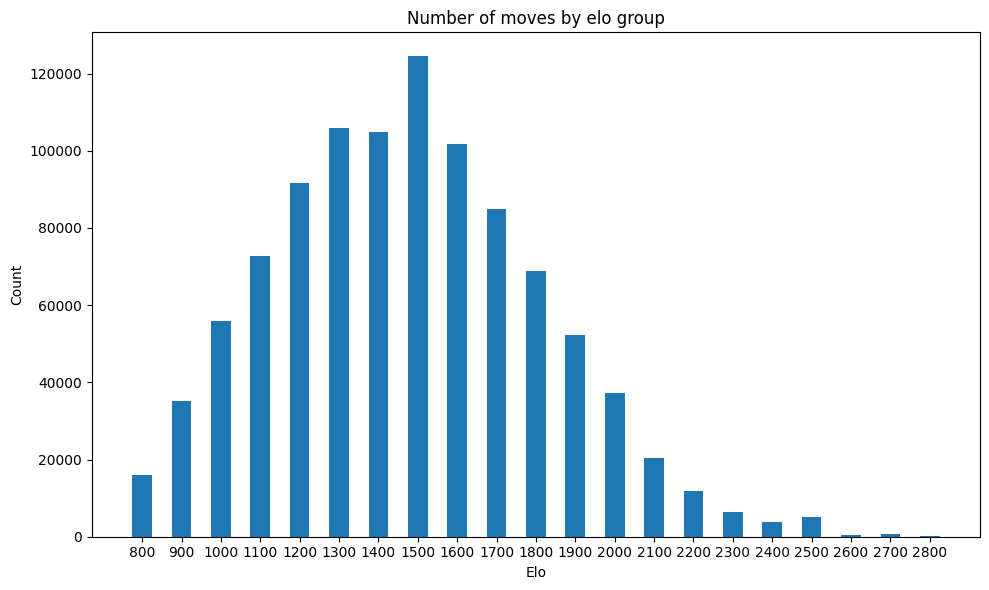

In [11]:
bar_plot(elo_groups, binned_counts)

In [12]:
elo_dict = dict(zip(elo_groups, binned_counts))


In [13]:
elo_dict[1700]/sum(elo_dict.values())*100

8.4832

In [14]:
execute_query(SQLITE_2_PATH, "DELETE FROM moves WHERE white_elo < 1700 OR white_elo >= 1800;")
execute_query(SQLITE_2_PATH, "DELETE FROM moves WHERE type = 'Bullet' OR type = 'UltraBullet' OR type = 'Correspondence';")
execute_query(SQLITE_2_PATH, "DELETE FROM moves WHERE white_active = 0;")

[]

In [15]:
drop_columns = ['result', 'white_player', 'black_player', 'black_elo', 'time_control', 'termination', 'white_won', 'black_won', 'no_winner', 'num_ply', 'winrate', 'winrate_elo', 'winrate_loss', 'is_blunder_wr', 'opp_winrate', 'active_elo', 'opponent_elo', 'active_won', 'is_capture', 'clock', 'opp_clock', 'clock_percent', 'opp_clock_percent', 'active_bishop_count', 'active_knight_count','active_pawn_count','active_queen_count','active_rook_count', 'opp_bishop_count', 'opp_knight_count','opp_pawn_count','opp_queen_count','opp_rook_count']

In [16]:
for column in drop_columns:
    execute_query(SQLITE_2_PATH, "ALTER TABLE moves DROP COLUMN {};".format(column))
execute_query(SQLITE_2_PATH, "VACUUM;")

[]

In [17]:
execute_query(SQLITE_2_PATH, "PRAGMA table_info(moves);")

[(0, 'type', 'TEXT', 0, None, 0),
 (1, 'white_elo', 'INTEGER', 0, None, 0),
 (2, 'move_ply', 'INTEGER', 0, None, 0),
 (3, 'move', 'TEXT', 0, None, 0),
 (4, 'cp', 'TEXT', 0, None, 0),
 (5, 'cp_rel', 'REAL', 0, None, 0),
 (6, 'cp_loss', 'REAL', 0, None, 0),
 (7, 'is_blunder_cp', 'INTEGER', 0, None, 0),
 (8, 'white_active', 'INTEGER', 0, None, 0),
 (9, 'low_time', 'INTEGER', 0, None, 0),
 (10, 'board', 'TEXT', 0, None, 0),
 (11, 'is_check', 'INTEGER', 0, None, 0),
 (12, 'num_legal_moves', 'INTEGER', 0, None, 0)]

In [18]:
len(execute_query(SQLITE_2_PATH, "SELECT * FROM moves;"))

34462